# 1.Import Libraries

In [77]:
# Pandas is used for data manipulation
import pandas as pd

# Numpy is used for numerical computations
import numpy as np

# Matplotlib is used for data visualization
import matplotlib.pyplot as plt

# Seaborn provides better statistical plots
import seaborn as sns

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

# 2.Load Dataset

#### read_csv() loads the dataset into a pandas dataframe.

In [78]:
# Load dataset
df = pd.read_csv("ToyotaCorolla - MLR.csv")

# Display first five rows
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


# 3.Basic Data Exploration

In [79]:
# Check column names
df.columns

Index(['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc',
       'Doors', 'Cylinders', 'Gears', 'Weight'],
      dtype='object')

In [80]:
# Check dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [81]:
# Statistical summary
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


## describe() Purpose: check data types, understand distribution, detect missing values

# 4.Missing Values

In [84]:
# Count missing values
df.isna().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

# 5.Remove Duplicates

In [86]:
# Check duplicates
df.duplicated().sum()

1

In [88]:
# Remove duplicates
df.drop_duplicates(inplace=True,ignore_index=True)

# 6.Outlier Detection

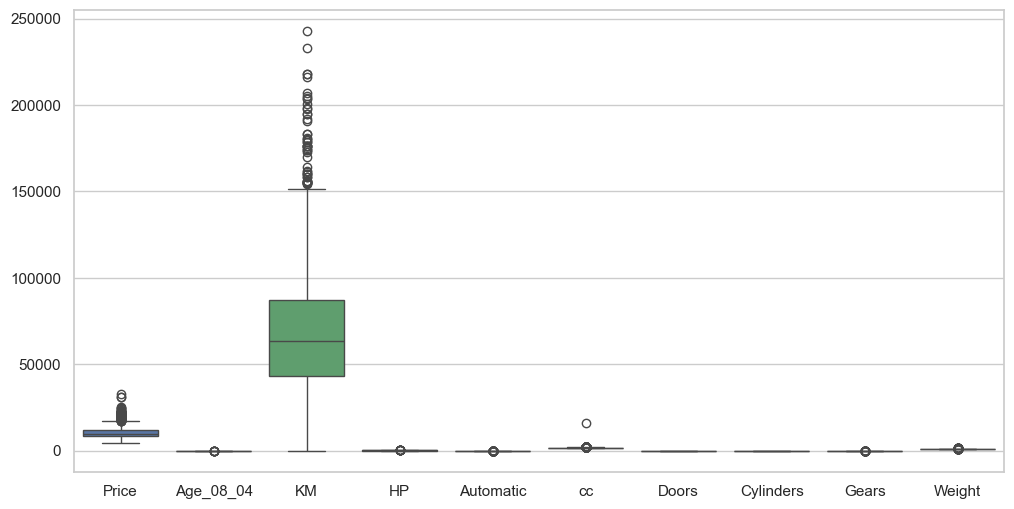

In [89]:
# Boxplot for outlier visualization
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.show()

# 7.Outlier Capping

In [90]:
# Function to cap outliers
def outlier_capping(df,column):

    q1=df[column].quantile(0.25)
    q3=df[column].quantile(0.75)

    iqr=q3-q1

    lower=q1-1.5*iqr
    upper=q3+1.5*iqr

    df[column]=df[column].clip(lower,upper)

## IQR = Q3 − Q1 --> Used to detect extreme values.

# 8.Data Visualization

### Histogram

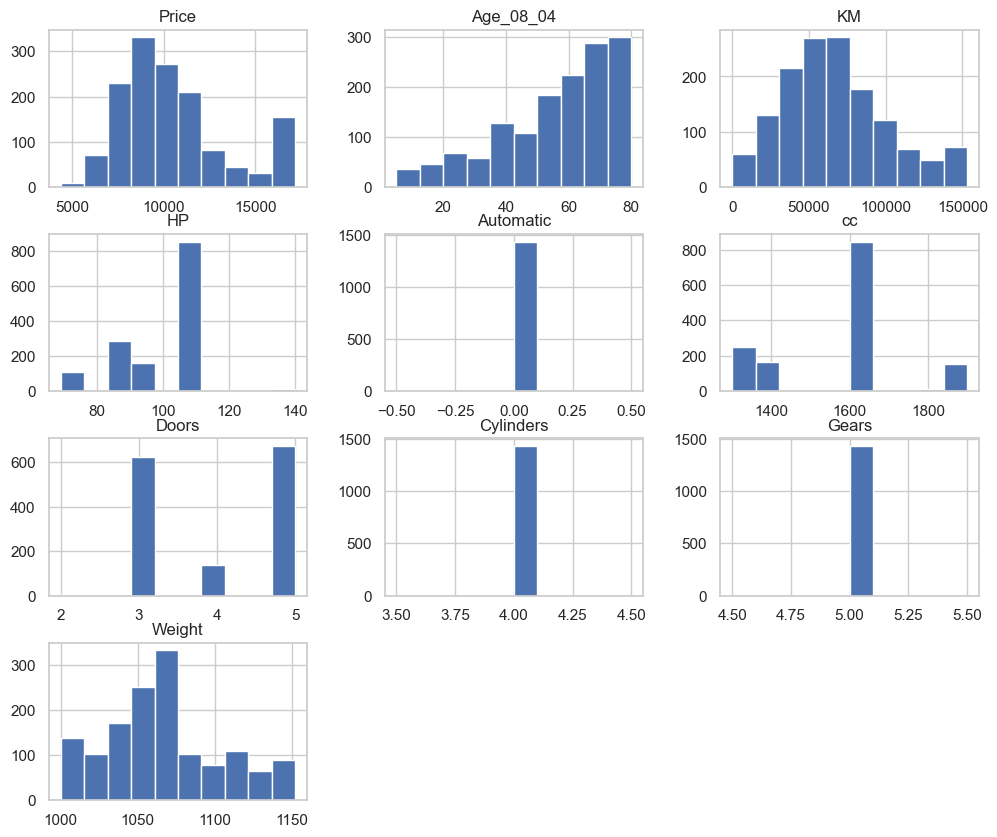

In [92]:
df.hist(figsize=(12,10))
plt.show()

## Histogram Purpose: Understand variable distribution.

# 9.Encode Categorical Variables

## Correlation Heatmap

In [ ]:
# Convert categorical variable into numeric
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
df['Fuel_Type'] = label.fit_transform(df['Fuel_Type'])

### Now the values become:
### Fuel_Type	Encoded
### CNG	            0
### Diesel	        1
### Petrol	        2

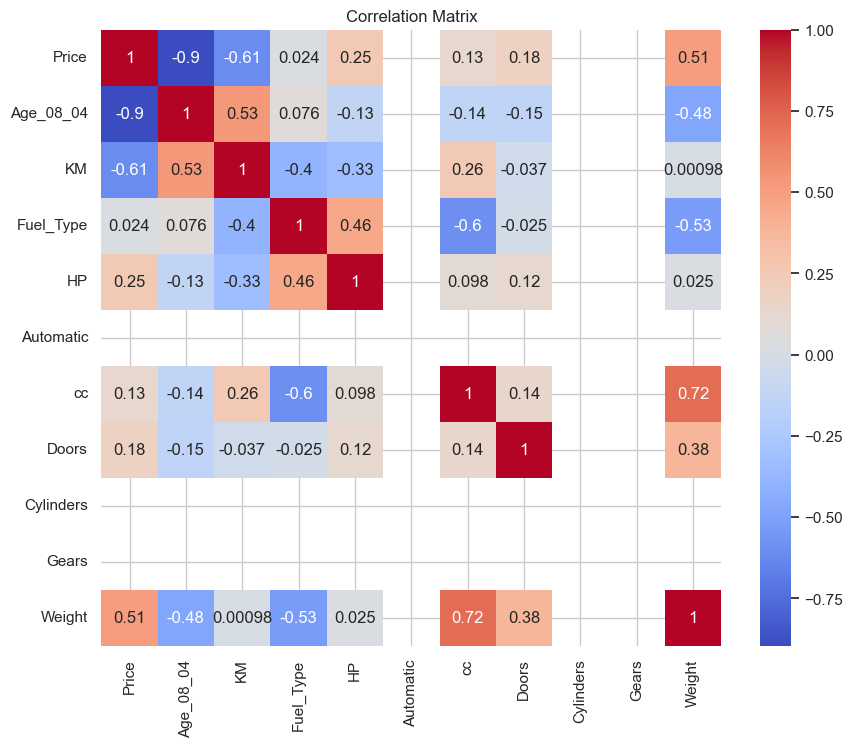

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# 10.Define Features and Target

In [97]:
# Independent variables
X=df.drop("Price",axis=1)

# Dependent variable
y=df["Price"]

### Target variable --> variable we predict.

# 11.Train Test Split

In [98]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

### 80% training data and 20% testing data

# 12.Build Linear Regression Model

In [100]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()

model.fit(X_train,y_train)
#fit() trains the model.

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# 13.Model Coefficients

In [101]:
coeff=pd.DataFrame(model.coef_,X.columns,columns=["Coefficient"])

coeff

,Coefficient
Age_08_04,-1.052788e+02
KM,-1.494867e-02
Fuel_Type,4.606794e+02
HP,2.349020e+01
Automatic,-6.838974e-13
cc,-2.191651e+00
Doors,-1.314006e+02
Cylinders,0.000000e+00
Gears,0.000000e+00
Weight,2.578226e+01


# 14.Prediction

In [102]:
y_pred=model.predict(X_test)

# 15.Model Evaluation

In [103]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 16.R² Score

### R² shows how well the model explains variance.
### Range:
### 0 --> poor model
### 1 --> perfect model

In [104]:
r2_score(y_test,y_pred)

0.850039183654592

# RMSE

In [105]:
rmse=np.sqrt(mean_squared_error(y_test,y_pred))

rmse

1130.8865418187117

### Lower RMSE = better model.

# 16.Ridge Regression



### Used to reduce overfitting.

In [106]:
from sklearn.linear_model import Ridge

ridge=Ridge(alpha=1)

ridge.fit(X_train,y_train)

ridge_pred=ridge.predict(X_test)

r2_score(y_test,ridge_pred)

0.8499914366358213

# 17.Lasso Regression

### Used for feature selection.

In [107]:
from sklearn.linear_model import Lasso

lasso=Lasso(alpha=0.1)

lasso.fit(X_train,y_train)

lasso_pred=lasso.predict(X_test)

r2_score(y_test,lasso_pred)

0.8500296456888049

# 18.Scatter Plot (Actual vs Predicted)

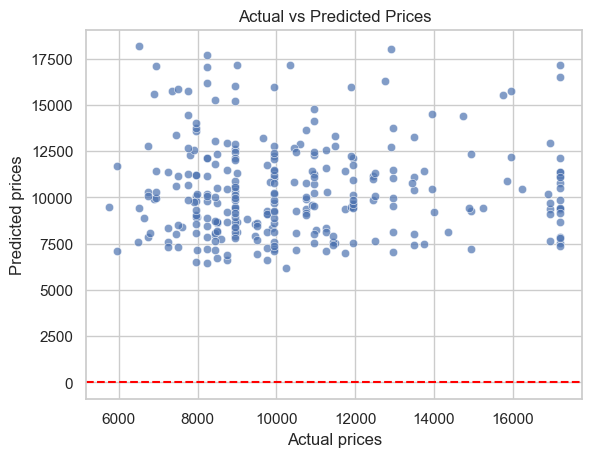

In [108]:

sns.scatterplot(x=y_test.values.flatten(), y=y_preds.flatten(), alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Actual prices")
plt.ylabel("Predicted prices")
plt.title("Actual vs Predicted Prices")
plt.show()

### this plot compares: Actual prices (true values) and Predicted prices (model output)
### Each point represents one prediction.

# 19.Regression Plot

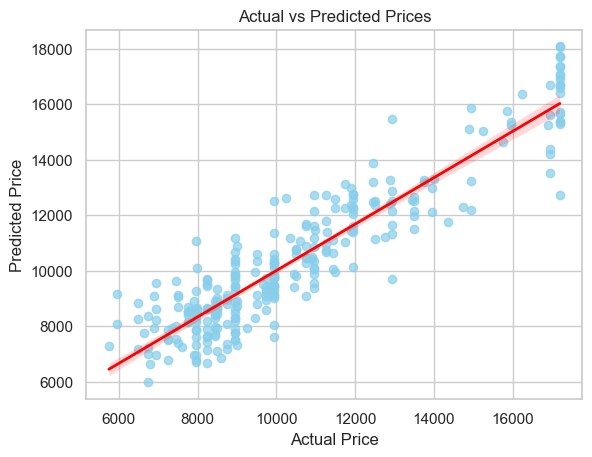

In [109]:
sns.regplot(
    x=y_test,
    y=y_pred,
    scatter_kws={'color': 'skyblue', 'alpha': 0.7},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

### This shows: actual vs predicted values, best fit regression line
### It helps visualize the relationship between actual and predicted values.

## I Performed exploratory data analysis, handled outliers using IQR capping, encoded categorical variables, built multiple linear regression models, and evaluated performance using R² and RMSE. I also applied Ridge and Lasso regularization to reduce multicollinearity and overfitting


# Interview Questions:

## 1.What is Normalization & Standardization and how is it helpful? 

### Normalization and standardization are data scaling techniques used in machine learning. Normalization scales data to a range between 0 and 1, while standardization transforms data to have a mean of zero and a standard deviation of one. These techniques help improve model performance by ensuring that all features contribute equally to the learning process.

# 2.What techniques can be used to address multicollinearity in multiple linear regression?


### Multicollinearity in multiple linear regression can be addressed by removing highly correlated variables, using Variance Inflation Factor (VIF) to detect multicollinearity, applying regularization techniques like Ridge and Lasso regression, or using dimensionality reduction methods such as Principal Component Analysis